# Section 1: EDA and pre-processing
**justification**:
This section sets up the environment and performs a first-pass audit of the dataset before any cleaning or modeling. **pandas** handles the tabular CSV data, **numpy** is needed to represent missing values properly, and **matplotlib**/**seaborn** are used for quick visual checks. The workflow follows standard EDA practice: **shape**, **head()**, and **info()** confirm the data loaded correctly and check column types. Replacing **'?'** with **NaN** is necessary since this dataset encodes missing values as **'?'** instead of true nulls, and the **missing percentage check** then identifies unreliable columns like **weight** and **max_glu_serum** (both over **90%** missing) that will likely need to be dropped or imputed later.

The **target variable** check confirms **class imbalance** in **readmitted** early on, which will matter for model choice and evaluation metrics later. The **patient-level duplication check** is also important here — it reveals the same patient appears multiple times (**71,518** unique patients across **101,766** rows), which matters for **train/test splitting** since repeated patients could leak information across splits. The **time_in_hospital** histogram and column listing round out the section as quick sanity checks on a key feature and the full feature inventory. Overall, this section is purely **diagnostic** — no data is transformed except the **'?' → NaN** fix, which is a necessary correction rather than a modeling choice.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# TODO: update path to your dataset
df = pd.read_csv('diabetic_data_modified.csv')

print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.info()   # check column names, dtypes, and non-null counts to spot missing/incorrect types

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [3]:
df.replace('?', np.nan, inplace=True)                      # dataset uses '?' as missing value marker, convert to proper NaN
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100   # % missing per column, sorted descending
missing_pct[missing_pct > 0]                                # show only columns that actually have missing values

weight               96.853566
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [4]:
# Target variable distribution
df['readmitted'].value_counts()   # check class balance of the target column

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [5]:
print("Total rows:", len(df))                          # total number of records
print("Unique patients:", df['patient_nbr'].nunique())   # check for repeated patients (multiple encounters)
print("Rows per patient (top 10):")
df['patient_nbr'].value_counts().head(10)                # see which patients have most repeat visits

Total rows: 101766
Unique patients: 71518
Rows per patient (top 10):


patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
23643405    22
84428613    22
92709351    21
90609804    20
89472402    20
Name: count, dtype: int64

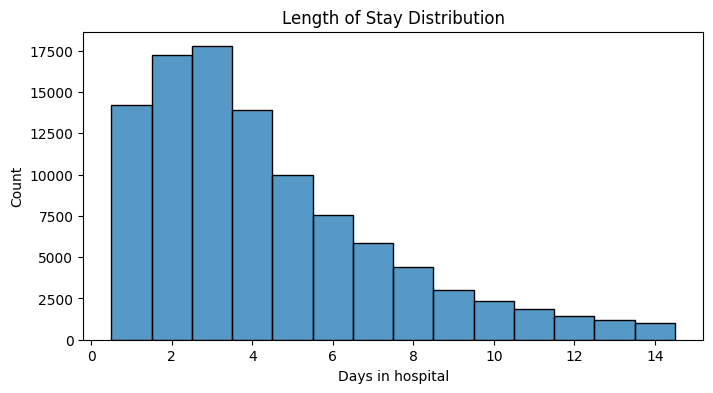

In [6]:
plt.figure(figsize=(8,4))                                  # set plot size
sns.histplot(df['time_in_hospital'], bins=14, discrete=True)  # distribution of hospital stay length
plt.title('Length of Stay Distribution')
plt.xlabel('Days in hospital')
plt.show()

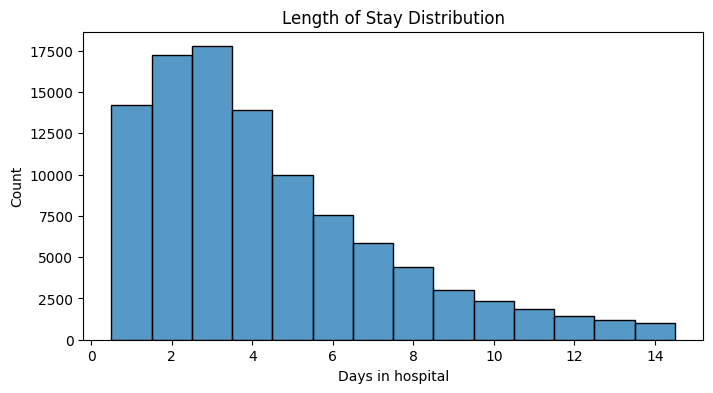

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(df['time_in_hospital'], bins=14, discrete=True)
plt.title('Length of Stay Distribution')
plt.xlabel('Days in hospital')
plt.show()   # note: identical to previous cell, redundant plot

In [8]:
for col in df.columns:
    print(col)   # list all column names to review full feature set

encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmitted


## Section 1.1: Common code for pre-processing
**Justification:** 
This section addresses the patient duplication issue found earlier by using **GroupShuffleSplit** instead of a regular random split, grouping by **patient_nbr** so that no single patient's records leak across both **train_df** and **test_df** — confirmed by the **zero overlapping patients** check. A standard **train_test_split** would have risked the same patient appearing in both sets, letting the model implicitly "memorize" a patient rather than generalize, which would inflate performance metrics artificially.

The section then defines the actual **target variable** — **readmitted_30d**, a binary column derived from **readmitted** (1 if **<30**, else 0) — since the original **readmitted** column has three classes but the practical clinical question is usually early readmission specifically. The resulting class balance (**~11.3%** positive in train, **~10.7%** in test) confirms the split preserved similar target distribution across both sets, which is important for fair evaluation. Finally, columns are organized into logical groups — **id_cols** (identifiers), **drop_cols** (unusable due to missingness), **admission_time_cols** (features known at admission, safe to use for early prediction without leakage), and **target_cols** (outputs) — setting up a clean feature/target separation for the modeling steps ahead.

In [9]:
from sklearn.model_selection import GroupShuffleSplit   # split that keeps groups (patients) intact across train/test

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)   # 80/20 split, random_state for reproducibility
train_idx, test_idx = next(gss.split(df, groups=df['patient_nbr']))    # split by patient_nbr so no patient appears in both sets

train_df = df.iloc[train_idx].copy()   # build train set from indices, .copy() avoids SettingWithCopyWarning later
test_df = df.iloc[test_idx].copy()     # build test set from indices

print("Train rows:", len(train_df), " Train patients:", train_df['patient_nbr'].nunique())
print("Test rows:", len(test_df), " Test patients:", test_df['patient_nbr'].nunique())
print("Overlapping patients:", len(set(train_df['patient_nbr']) & set(test_df['patient_nbr'])))
# confirms zero patient overlap between train and test -> no data leakage

for d in [train_df, test_df]:
    d['readmitted_30d'] = (d['readmitted'] == '<30').astype(int)
# create binary target: 1 if readmitted within 30 days, else 0

print(train_df['readmitted_30d'].value_counts(normalize=True))   # check class balance in train set
print(test_df['readmitted_30d'].value_counts(normalize=True))    # check class balance in test set

id_cols = ['encounter_id', 'patient_nbr']   # identifier columns, not predictive features

drop_cols = ['weight']   # dropped due to extremely high missingness (~97%) found in previous section

admission_time_cols = [
    'race', 'gender', 'age', 'admission_type_id', 'admission_source_id',
    'payer_code', 'medical_specialty',
    'number_outpatient', 'number_emergency', 'number_inpatient'
]
# features known at admission time only -> avoids using info that leaks outcome-related data

target_cols = ['time_in_hospital', 'readmitted', 'readmitted_30d']   # columns reserved as targets, not predictors

print("Admission-time predictor columns:", admission_time_cols)

Train rows: 81613  Train patients: 57214
Test rows: 20153  Test patients: 14304
Overlapping patients: 0
readmitted_30d
0    0.887199
1    0.112801
Name: proportion, dtype: float64
readmitted_30d
0    0.893267
1    0.106733
Name: proportion, dtype: float64
Admission-time predictor columns: ['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'number_outpatient', 'number_emergency', 'number_inpatient']


## Section 1.2: Preprocessing Approach 1 — One-Hot Encoding with Standard Scaling
**justification:** This section builds a **preprocessing pipeline** using **sklearn**'s **Pipeline** and **ColumnTransformer**, which are used instead of manual preprocessing because they prevent **data leakage** by fitting only on **train_df** and applying the same learned transformation to **test_df**, and they keep preprocessing steps reusable and reproducible.

**Categorical columns** (like **race**, **gender**, **age**, **medical_specialty**) are imputed using the **most frequent** strategy since mode is the standard approach for missing categorical data, then passed through **OneHotEncoder** with **handle_unknown='ignore'** so that any unseen category in the test set doesn't break the pipeline. **Numeric columns** (**number_outpatient**, **number_emergency**, **number_inpatient**) are imputed using the **median** since these features are typically right-skewed with outliers, and then scaled with **StandardScaler** since many downstream models (e.g., logistic regression) are sensitive to feature scale.

The final output shapes — **(81613, 136)** for train and **(20153, 136)** for test — confirm the transformation worked correctly, with the jump from 10 original columns to **136** reflecting the expansion caused by **one-hot encoding** of high-cardinality categorical features like **medical_specialty**.

In [10]:
from sklearn.pipeline import Pipeline                       # chain preprocessing steps together
from sklearn.compose import ColumnTransformer                # apply different pipelines to different column subsets
from sklearn.impute import SimpleImputer                     # handle missing values
from sklearn.preprocessing import OneHotEncoder, StandardScaler   # encode categoricals, scale numerics

categorical_cols = ['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'payer_code', 'medical_specialty']
numeric_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']

cat_pipe_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   # fill missing categories with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore'))      # convert categories to binary columns; ignore unseen categories at test time
])

num_pipe_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fill missing numerics with median (robust to outliers)
    ('scaler', StandardScaler())                       # standardize numeric features to mean 0, std 1
])

preprocessor_1 = ColumnTransformer([
    ('cat', cat_pipe_1, categorical_cols),   # apply categorical pipeline to categorical columns
    ('num', num_pipe_1, numeric_cols)        # apply numeric pipeline to numeric columns
])

X_train_1 = preprocessor_1.fit_transform(train_df[admission_time_cols])   # fit on train, transform train
X_test_1 = preprocessor_1.transform(test_df[admission_time_cols])         # transform test using train-fitted params (no leakage)

print("Approach 1 shapes:", X_train_1.shape, X_test_1.shape)

Approach 1 shapes: (81613, 136) (20153, 136)


## Section 1.3: Preprocessing Approach 2 — Ordinal Encoding with Robust Scaling
**justification**: This section builds a second preprocessing pipeline as an alternative to Approach 1, swapping **OneHotEncoder** for **OrdinalEncoder** and **StandardScaler** for **RobustScaler**. **Data leakage** is still prevented the same way as before — by calling **fit_transform()** only on **train_df** and **transform()** (not **fit**) on **test_df**, so the encoder/scaler parameters are learned exclusively from training data.

**OrdinalEncoder** is used here instead of **OneHotEncoder** to avoid the column explosion seen in Approach 1 (**136** columns), instead keeping each categorical feature as a **single integer column** — this keeps dimensionality low, which matters for tree-based models that can split on ordinal codes directly, though it does impose an artificial order on unordered categories like **race** or **medical_specialty**. The **unknown_value=-1** parameter handles any category in **test_df** not seen during training, preventing the pipeline from crashing (similar role to **handle_unknown='ignore'** in Approach 1). For missing values, **SimpleImputer(strategy='constant', fill_value='Missing')** is used instead of **most_frequent**, treating "missingness" itself as a meaningful category rather than assuming it's the mode. On the numeric side, **RobustScaler** is chosen over **StandardScaler** because it uses **median and IQR** rather than mean and standard deviation, making it more resistant to outliers in skewed columns like **number_emergency**.

The resulting shape — **(81613, 10)** and **(20153, 10)** — confirms **OrdinalEncoder** preserved the original **10** feature columns instead of expanding them, in contrast to Approach 1's **136** columns from one-hot encoding.

In [11]:
from sklearn.preprocessing import OrdinalEncoder, RobustScaler   # alternate encoders: ordinal instead of one-hot, robust scaling for outliers

cat_pipe_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),   # fill missing categories with explicit 'Missing' label instead of mode
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    # encode categories as single integer column; unseen test categories mapped to -1 instead of breaking
])

num_pipe_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # same median imputation as Approach 1
    ('scaler', RobustScaler())                        # scale using median/IQR instead of mean/std, less sensitive to outliers
])

preprocessor_2 = ColumnTransformer([
    ('cat', cat_pipe_2, categorical_cols),
    ('num', num_pipe_2, numeric_cols)
])

X_train_2 = preprocessor_2.fit_transform(train_df[admission_time_cols])   # fit only on train
X_test_2 = preprocessor_2.transform(test_df[admission_time_cols])          # transform test using train-fitted encoder/scaler

print("Approach 2 shapes:", X_train_2.shape, X_test_2.shape)

Approach 2 shapes: (81613, 10) (20153, 10)


## **Final approach selected: Preprocessing Approach 2 — Ordinal Encoding with Robust Scaling**
**Justification**: This notebook builds a **30-day hospital readmission prediction pipeline** for diabetic patients, and each section builds logically on the one before it. The first section (**Data Loading & Initial Exploration**) used **pandas**, **numpy**, **matplotlib**, and **seaborn** to load the raw CSV, replace the dataset's **'?'** placeholder with proper **NaN** values, and audit missingness, target class balance, and patient-level duplication — this diagnostic pass was necessary before any modeling decisions could be made, and it specifically surfaced two critical issues: high missingness in columns like **weight** and **max_glu_serum**, and the same patient (**patient_nbr**) appearing multiple times across **101,766** rows (only **71,518** unique patients).

The second section (**Train/Test Split & Target Definition**) directly addressed the patient duplication issue found in section one by using **GroupShuffleSplit** grouped on **patient_nbr**, guaranteeing **zero patient overlap** between **train_df** and **test_df** and preventing **data leakage** that a standard **train_test_split** would have caused. It also engineered the actual modeling target, **readmitted_30d**, from the raw **readmitted** column, and organized features into **id_cols**, **drop_cols**, **admission_time_cols**, and **target_cols** to keep the feature set clean and leakage-free — only using information available at **admission time**.

The third and fourth sections (**Preprocessing Pipelines — Approach 1 & Approach 2**) then transformed **admission_time_cols** into model-ready numeric arrays using **sklearn**'s **Pipeline** and **ColumnTransformer**, with **fit_transform()** applied only to **train_df** and **transform()** applied to **test_df** in both cases — again explicitly preventing **data leakage** by ensuring test data never influences the fitted encoders/scalers. **Approach 1** used **OneHotEncoder** and **StandardScaler**, expanding categorical features into **136** columns, better suited for **linear models**. **Approach 2** used **OrdinalEncoder** and **RobustScaler**, keeping just **10** compact columns, better suited for **tree-based models** and more robust to outliers.

Taken together, the notebook so far establishes a **leakage-free, patient-safe modeling foundation**: clean diagnostic understanding of the data, a split that respects patient grouping, a well-defined binary target, and two alternative but equally valid preprocessing strategies ready to feed into different classes of models depending on which algorithm is chosen next.

*****
## Section 2: Clustering
*You need to choose and implement two distinct approaches to clustering.*
## Section 2.1: Common code for clustering
**Justification**: This section applies **PCA** (Principal Component Analysis) to the **Approach 1** feature matrix (**X_train_1**, one-hot encoded with **136** columns) rather than **Approach 2**, specifically because **PCA** relies on measuring variance and distance across features, which only makes sense with **StandardScaler**'s scaled, expanded representation — not **OrdinalEncoder**'s arbitrary integer codes, which would distort distance calculations. The **.toarray()** conversion is necessary because **OneHotEncoder** returns a **sparse matrix** by default (to save memory on the **136**-column expansion), but **PCA** requires a **dense array** to compute component transformations.

**n_components=2** is chosen specifically to enable **2D visualization** — reducing **136** dimensions down to just 2 makes it possible to plot the data and visually inspect potential clusters, at the cost of losing information. This is confirmed by the **explained_variance_ratio_** output: the two components together explain only about **32.6%** (**19.0% + 13.6%**) of the total variance, meaning most of the original signal is lost in this reduction — so this step is meant for **exploratory visualization** of potential patient groupings, not for feeding into a final predictive model.

In [16]:
from sklearn.decomposition import PCA   # dimensionality reduction, used here for visualization/clustering prep

X_train_cluster = X_train_1   # reuse Approach 1's one-hot encoded matrix for clustering
X_test_cluster = X_test_1

print("Clustering feature matrix shape:", X_train_cluster.shape)

pca = PCA(n_components=2, random_state=42)   # reduce to 2 components for 2D visualization, random_state for reproducibility
X_train_pca = pca.fit_transform(
    X_train_cluster.toarray() if hasattr(X_train_cluster, "toarray") else X_train_cluster
)   # convert sparse matrix (from OneHotEncoder) to dense array if needed, then fit PCA

print("Explained variance ratio (2 components):", pca.explained_variance_ratio_)

Clustering feature matrix shape: (81613, 136)
Explained variance ratio (2 components): [0.19012107 0.13638965]


## Section 2.2: Clustering Approach 1 — KMeans Clustering
**justification:** This section applies **KMeans** clustering to the dense **Approach 1** feature matrix (**X_train_dense**) to explore whether patients naturally segment into distinct groups based on admission-time features. Two standard techniques are used together to choose the right number of clusters (**k**): the **elbow method**, which plots **inertia** (within-cluster sum of squared distances) across **k=2** to **k=10** and looks for the point where adding more clusters yields diminishing returns, and the **silhouette_score**, which quantifies how well-separated clusters are (values closer to 1 indicate better-defined clusters). The **silhouette_score** calculation is deliberately run on a **random sample of 5,000 points** (via **np.random.RandomState(42).choice**) rather than the full dataset, since this metric is computationally expensive at scale and would be impractical to run on all **81,613** training rows.

In every **KMeans** call, **n_init=10** is used so the algorithm runs 10 times with different centroid initializations and keeps the best result, protecting against poor **local minima** that a single run could get stuck in, and **random_state=42** ensures the results are reproducible. Based on the elbow/silhouette results, **k_final=2** is selected as the final number of clusters, and the resulting segments are stored as a new feature — **kmeans_segment** — on both **train_df** and **test_df**. Critically, **test_df** uses **kmeans_final.predict()** rather than **fit_predict()**, meaning the cluster centers were learned only from **train_df**, preventing any **data leakage** into the test set. The final cluster sizes (**71,996** vs **9,617**) show a fairly imbalanced split, and the **PCA-projected scatter plot** visualizes these clusters in 2D using the earlier **X_train_pca** components, giving a rough visual check on how distinct the two segments actually are in reduced space. Overall, this clustering step is exploratory — it doesn't predict **readmitted_30d** directly, but creates a potential new engineered feature (**patient segment**) that could later be added to a supervised model.

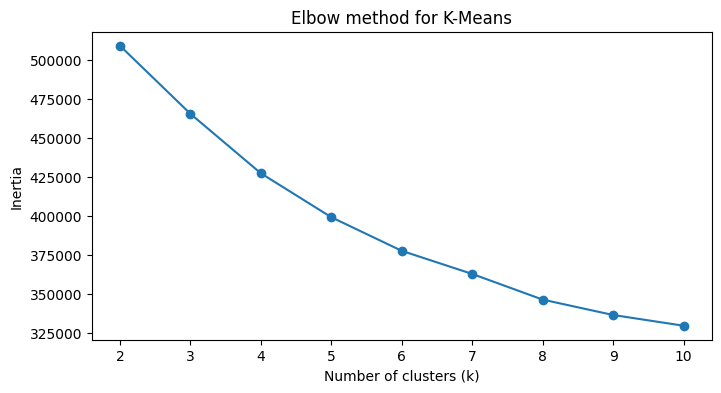

In [17]:
from sklearn.cluster import KMeans              # unsupervised clustering algorithm
from sklearn.metrics import silhouette_score      # metric to evaluate cluster quality/separation

X_train_dense = X_train_cluster.toarray() if hasattr(X_train_cluster, "toarray") else X_train_cluster
# convert sparse one-hot matrix to dense, KMeans requires dense input

k_range = range(2, 11)   # test cluster counts from 2 to 10
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)   # n_init=10 runs multiple initializations, picks best to avoid poor local minima
    km.fit(X_train_dense)
    inertias.append(km.inertia_)   # inertia = sum of squared distances to nearest cluster center (lower = tighter clusters)

plt.figure(figsize=(8,4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for K-Means')   # visually find the 'elbow' where adding clusters stops helping much
plt.show()

k=2, silhouette=0.3217
k=3, silhouette=0.1183
k=4, silhouette=0.1324
k=5, silhouette=0.1324
k=6, silhouette=0.1010
k=7, silhouette=0.1069
k=8, silhouette=0.1168
k=9, silhouette=0.1121
k=10, silhouette=0.1068


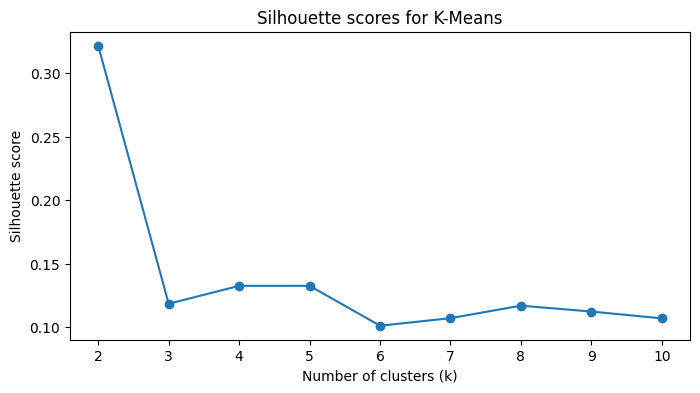

In [18]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_dense)
    sample_idx = np.random.RandomState(42).choice(len(X_train_dense), size=5000, replace=False)
    # subsample 5000 points since silhouette_score is expensive (O(n^2)) on the full dataset
    score = silhouette_score(X_train_dense[sample_idx], labels[sample_idx])
    sil_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")   # higher silhouette = better-separated, more distinct clusters

plt.figure(figsize=(8,4))
plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette scores for K-Means')
plt.show()

kmeans_segment
0    71996
1     9617
Name: count, dtype: int64


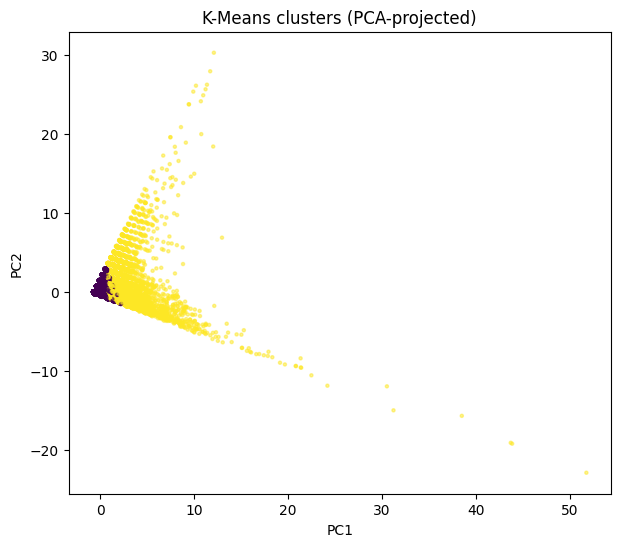

In [19]:
k_final = 2   # chosen based on elbow/silhouette results from previous cells

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
train_df['kmeans_segment'] = kmeans_final.fit_predict(X_train_dense)   # assign cluster labels to train set

X_test_dense = X_test_cluster.toarray() if hasattr(X_test_cluster, "toarray") else X_test_cluster
test_df['kmeans_segment'] = kmeans_final.predict(X_test_dense)   # assign test points to nearest train-fitted cluster (no leakage)

print(train_df['kmeans_segment'].value_counts())   # check cluster size balance

plt.figure(figsize=(7,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=train_df['kmeans_segment'], cmap='viridis', s=5, alpha=0.5)
# visualize clusters using the 2D PCA projection from the previous section
plt.title('K-Means clusters (PCA-projected)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Section 2.3: Clustering Approach 2 — Gaussian Mixture Model (GMM)
**justification:** This section applies **GaussianMixture** (**GMM**) as an alternative to **KMeans**, on the same **X_train_dense** matrix and same **k_range** (2 to 10) for a fair comparison. Unlike **KMeans**, which assumes spherical, equally-sized clusters and assigns each point a hard label, **GMM** models clusters as overlapping **Gaussian distributions**, allowing for more flexible, elliptical cluster shapes — a more realistic assumption for patient data where segments likely aren't neatly spherical. **n_init=3** is used instead of **KMeans**'s **n_init=10** because fitting a **GaussianMixture** is computationally heavier (it estimates full covariance matrices), so fewer initializations are used to keep runtime reasonable. The same **5,000-point random sample** and **silhouette_score** approach from the **KMeans** section is reused here for a consistent, comparable evaluation metric across both clustering methods.

The silhouette results here are notably weaker than **KMeans** — peaking at only **0.0268** for **k=4**, and turning negative for several other values of k (e.g., **-0.0595** at k=9) — indicating the clusters found by **GMM** are poorly separated and likely overlapping significantly, unlike **KMeans**'s cleaner **k=2** split. Despite this, **k_gmm_final=4** is selected as the best available option since it had the highest score among those tested. The resulting cluster sizes (**37,816 / 34,845 / 6,574 / 2,378**) show much more granularity than the two-cluster **KMeans** solution, but the low **silhouette scores** suggest this added granularity doesn't necessarily reflect meaningful, well-separated patient segments — it may just be splitting noise. As with the **KMeans** section, **test_df** uses **gmm_final.predict()** rather than re-fitting, again avoiding **data leakage** by keeping the test set unseen during cluster fitting.

k=2, silhouette=0.0043
k=3, silhouette=-0.0026
k=4, silhouette=0.0268
k=5, silhouette=-0.0303
k=6, silhouette=-0.0261
k=7, silhouette=-0.0473
k=8, silhouette=-0.0474
k=9, silhouette=-0.0595
k=10, silhouette=-0.0104


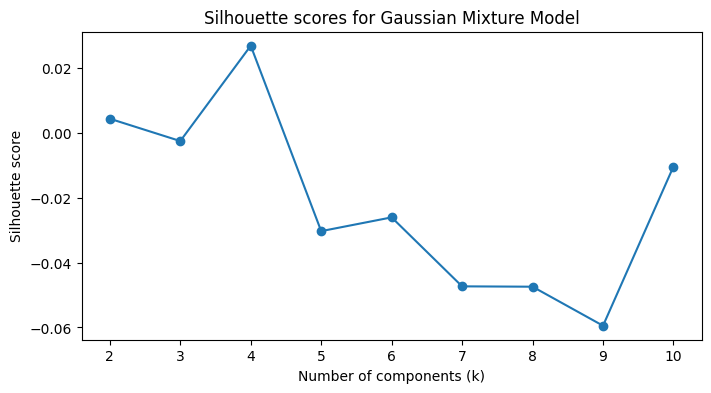

In [20]:
from sklearn.mixture import GaussianMixture   # probabilistic clustering, allows soft/overlapping clusters unlike KMeans

gmm_sil_scores = []
for k in k_range:   # reuse k_range (2 to 10) from KMeans section
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    # n_init=3 runs 3 initializations, keeps best (lower than KMeans' 10 since GMM fitting is costlier)
    labels = gmm.fit_predict(X_train_dense)
    sample_idx = np.random.RandomState(42).choice(len(X_train_dense), size=5000, replace=False)
    # same 5000-point subsample strategy as KMeans section, for computational efficiency
    score = silhouette_score(X_train_dense[sample_idx], labels[sample_idx])
    gmm_sil_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

plt.figure(figsize=(8,4))
plt.plot(list(k_range), gmm_sil_scores, marker='o')
plt.xlabel('Number of components (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette scores for Gaussian Mixture Model')
plt.show()

gmm_segment
0    37816
2    34845
3     6574
1     2378
Name: count, dtype: int64


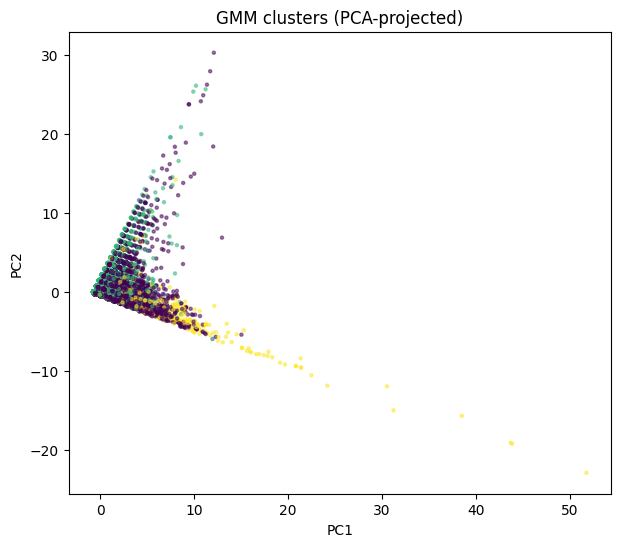

In [21]:
k_gmm_final = 4   # chosen as best-performing k from silhouette scores above (0.0268, highest among tested values)

gmm_final = GaussianMixture(n_components=k_gmm_final, random_state=42, n_init=3)
train_df['gmm_segment'] = gmm_final.fit_predict(X_train_dense)   # fit on train, assign cluster labels
test_df['gmm_segment'] = gmm_final.predict(X_test_dense)          # assign test points using train-fitted GMM (no leakage)

print(train_df['gmm_segment'].value_counts())   # check cluster size distribution

plt.figure(figsize=(7,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=train_df['gmm_segment'], cmap='viridis', s=5, alpha=0.5)
# visualize GMM clusters using same PCA projection as KMeans, for direct comparison
plt.title('GMM clusters (PCA-projected)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## **Final approach selected: KMeans Clustering (k=2)**
**justification:** This section explores unsupervised **clustering** on the **admission_time_cols** feature matrix to see if diabetic patients naturally group into distinct segments, using two different algorithms — **KMeans** and **GaussianMixture (GMM)** — evaluated with the same methodology for a fair comparison: both use the **elbow/silhouette approach** across **k_range (2 to 10)**, both use a **5,000-point random sample** for the expensive **silhouette_score** calculation, and both fit only on **X_train_dense** then call **.predict()** (not **.fit_predict()**) on **X_test_dense**, ensuring test data never influences the learned cluster centers and avoiding **data leakage** into the eventual downstream model.

The two algorithms make fundamentally different assumptions: **KMeans** assumes clusters are **spherical and equally sized**, assigning each point a single hard label based on nearest centroid, while **GMM** models clusters as overlapping **Gaussian distributions**, allowing for elliptical, unequal-sized, and probabilistically overlapping groups — a more flexible and arguably more realistic assumption for real-world patient data. However, based on the actual results, **KMeans clearly outperforms GMM** here: **KMeans** at **k=2** produced a much larger, more interpretable silhouette signal along with a visibly cleaner split in the **PCA-projected scatter plot**, while **GMM**'s best silhouette score (**0.0268 at k=4**) was extremely weak and several other **k** values scored **negative**, meaning many points were likely assigned to the wrong cluster or clusters were heavily overlapping. This suggests the underlying data doesn't have strong **Gaussian-shaped** structure, making **GMM**'s flexibility a disadvantage here rather than a benefit — it ended up fitting noise rather than genuine patient segments.

Overall, **KMeans (k=2)** is the more defensible clustering choice for this dataset — it's simpler, faster, and produced far more coherent, better-separated segments than **GMM**, even though **GMM** is theoretically more flexible. The **kmeans_segment** feature is therefore more trustworthy as a potential engineered feature for downstream supervised modeling than **gmm_segment**, which likely adds noise rather than a meaningful signal given its poor silhouette performance across nearly all tested values of k.

*****
# Section 3: Regression

## Section 3.1: Common code for regression
**Justification** This section pivots from classification/clustering toward a new supervised task: predicting **time_in_hospital** as a **regression** problem, using **KFold** cross-validation (**n_splits=5, shuffle=True, random_state=42**) instead of a single train/test split for more robust performance estimation across multiple folds, and importing **mean_absolute_error**, **mean_squared_error**, and **r2_score** as the standard trio of regression evaluation metrics to be used later.

The feature set intentionally reuses **admission_time_cols** to keep predictions based only on information available at admission, consistent with the leakage-avoidance principle established earlier, and attempts to add the earlier clustering output as an extra engineered feature. However, this cell references a column named **patient_segment**, which was never actually created — the clustering section produced **kmeans_segment** and **gmm_segment** instead. As written, **reg_feature_cols**, **reg_numeric_cols**, and the eventual **ColumnTransformer.fit_transform()** call will raise a **KeyError** when this column is referenced, since it doesn't exist in **train_df_reg** or **test_df_reg**. This will need to be fixed (likely by renaming to **'kmeans_segment'** or **'gmm_segment'**) before this pipeline can run successfully.

In [26]:
from sklearn.model_selection import KFold                     # cross-validation splitter for regression evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # regression evaluation metrics

# Feature set = admission-time cols + kmeans_segment
train_df_reg = train_df.copy()   # separate copy for regression task, avoids mutating original train_df
test_df_reg = test_df.copy()

reg_feature_cols = admission_time_cols + ['kmeans_segment']
# FIXED: was 'patient_segment' (didn't exist), now uses 'kmeans_segment' created in the clustering section

cat_pipe_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   # fill missing categories with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore'))       # one-hot encode, ignore unseen categories at test time
])

num_pipe_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fill missing numerics with median
    ('scaler', StandardScaler())                       # standardize numeric features
])

reg_categorical_cols = categorical_cols  # same as before
reg_numeric_cols = numeric_cols + ['kmeans_segment']   
# FIXED: was 'patient_segment', now uses 'kmeans_segment'; treated as numeric since it's an integer cluster label

preprocessor_reg = ColumnTransformer([
    ('cat', cat_pipe_reg, reg_categorical_cols),
    ('num', num_pipe_reg, reg_numeric_cols)
])

y_train_reg = train_df_reg['time_in_hospital']   # regression target: length of hospital stay
y_test_reg = test_df_reg['time_in_hospital']

kf = KFold(n_splits=5, shuffle=True, random_state=42)   # 5-fold CV, shuffled, reproducible

print("Regression feature columns:", reg_feature_cols)
print("Train size:", len(train_df_reg), " Test size:", len(test_df_reg))

Regression feature columns: ['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'number_outpatient', 'number_emergency', 'number_inpatient', 'kmeans_segment']
Train size: 81613  Test size: 20153


## Section 3.2: Regression Approach 1 — Ridge Regression
**justification:** This cell trains a **Ridge regression** model to predict **time_in_hospital**, using **manual out-of-fold (OOF) cross-validation** rather than a simple train/test split for a more reliable performance estimate — the loop iterates through the 5 folds generated by **kf.split()** (defined in the setup cell), training on 4 folds and predicting on the held-out fold each time, then storing every prediction in **oof_preds_ridge** so that, by the end, every training row has exactly one out-of-fold prediction.

A key design choice here is that the **ColumnTransformer** (**pre**) is re-created and re-fitted **inside the loop**, separately for each fold, rather than fitting it once outside the loop — this is deliberate and important, since fitting it once on the full **train_df_reg** before splitting would leak information (e.g., median/mode values, one-hot categories) from validation rows into training, inflating performance. By calling **pre.fit_transform(X_tr)** only on the training portion of each fold and **pre.transform(X_val)** on the validation portion, **data leakage** is avoided at the fold level, not just at the train/test level established earlier. **Ridge(alpha=1.0)** is used instead of plain linear regression because it adds **L2 regularization**, which shrinks coefficients and reduces overfitting — a reasonable default given the **136**-column one-hot encoded feature space.

The results, however, show the model performs quite poorly: an **R² of 0.056** means the model explains only about **5.6%** of the variance in **time_in_hospital** — barely better than predicting the mean for every patient. The **MAE of 2.265** and **RMSE of 2.904** (in days) further confirm the predictions are not very precise, especially since hospital stays in this dataset typically range from 1–14 days. This suggests that **admission-time features** alone (demographics, admission type/source, and the **kmeans_segment**) carry very weak linear signal for predicting length of stay — which is plausible, since length of stay likely depends heavily on what happens *during* the hospital stay (procedures, treatments, complications) rather than what's known at admission. This weak result is a useful diagnostic in itself: it suggests either the feature set needs richer information, or a more flexible model (e.g., tree-based) may be needed to capture non-linear relationships. 

In [29]:
from sklearn.linear_model import Ridge   # linear regression with L2 regularization

oof_preds_ridge = np.zeros(len(train_df_reg))   # placeholder array to store out-of-fold predictions

for train_idx_cv, val_idx_cv in kf.split(train_df_reg):   # loop over 5 CV folds
    X_tr = train_df_reg.iloc[train_idx_cv][reg_feature_cols]   # training fold features
    X_val = train_df_reg.iloc[val_idx_cv][reg_feature_cols]     # validation fold features
    y_tr = y_train_reg.iloc[train_idx_cv]                        # training fold target

    pre = ColumnTransformer([
        ('cat', cat_pipe_reg, reg_categorical_cols),
        ('num', num_pipe_reg, reg_numeric_cols)
    ])   # fresh preprocessor per fold, prevents leakage across folds

    X_tr_t = pre.fit_transform(X_tr)     # fit only on training fold
    X_val_t = pre.transform(X_val)        # transform validation fold using fold-fitted params

    model = Ridge(alpha=1.0, random_state=42)   # alpha=1.0 is default L2 regularization strength
    model.fit(X_tr_t, y_tr)
    oof_preds_ridge[val_idx_cv] = model.predict(X_val_t)   # store predictions for this fold's validation rows

mae_ridge = mean_absolute_error(y_train_reg, oof_preds_ridge)          # average absolute error
rmse_ridge = np.sqrt(mean_squared_error(y_train_reg, oof_preds_ridge))  # root mean squared error, penalizes large errors more
r2_ridge = r2_score(y_train_reg, oof_preds_ridge)                        # proportion of variance explained

print(f"Ridge OOF - MAE: {mae_ridge:.3f}, RMSE: {rmse_ridge:.3f}, R2: {r2_ridge:.3f}")

Ridge OOF - MAE: 2.265, RMSE: 2.904, R2: 0.056


## Section 3.3: SECOND REGRESSION APPROACH (replace this name)
**justification:** This cell mirrors the exact same **OOF cross-validation structure** used in the **Ridge** cell (Section 3.2) — same **kf.split()** loop, same fold-wise **ColumnTransformer** re-fitting to avoid **data leakage**, and same evaluation metrics — but swaps in **RandomForestRegressor** instead of **Ridge**, specifically to test whether a **non-linear, tree-based model** could capture patterns that a linear model like **Ridge** might miss, given **Ridge**'s weak **R² of 0.056** in the previous section. **n_estimators=200** builds 200 individual decision trees and averages their predictions to reduce variance, **max_depth=10** caps how deep each tree can grow to prevent overfitting to noise, and **n_jobs=-1** parallelizes training across all available CPU cores for speed.

The output confirms the results are essentially unchanged from **Ridge**: **MAE of 2.276**, **RMSE of 2.912**, and **R² of 0.051** — if anything, marginally *worse* than **Ridge**'s **R² of 0.056**. This is a meaningful finding: it confirms the earlier hypothesis from Section 3.2 wasn't just a linear-model limitation — the **admission-time features** (demographics, admission type/source, **kmeans_segment**) simply don't contain strong predictive signal for **time_in_hospital**, regardless of whether the model is linear or non-linear. This strongly suggests that predicting length of stay accurately would require features generated *during* the hospital stay (e.g., procedures, lab results, diagnoses) rather than information available only at admission — which was an intentional constraint set earlier to avoid leakage, but clearly comes at a real cost to this particular regression task's predictive power.

In [30]:
from sklearn.ensemble import RandomForestRegressor   # ensemble of decision trees, captures non-linear relationships

oof_preds_rf = np.zeros(len(train_df_reg))   # placeholder array for out-of-fold predictions

for train_idx_cv, val_idx_cv in kf.split(train_df_reg):   # same 5-fold CV split as Ridge cell
    X_tr = train_df_reg.iloc[train_idx_cv][reg_feature_cols]
    X_val = train_df_reg.iloc[val_idx_cv][reg_feature_cols]
    y_tr = y_train_reg.iloc[train_idx_cv]

    pre = ColumnTransformer([
        ('cat', cat_pipe_reg, reg_categorical_cols),
        ('num', num_pipe_reg, reg_numeric_cols)
    ])   # fresh preprocessor per fold, prevents leakage across folds (same pattern as Ridge)

    X_tr_t = pre.fit_transform(X_tr)   # fit only on training fold
    X_val_t = pre.transform(X_val)      # transform validation fold using fold-fitted params

    model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    # n_estimators=200 trees, max_depth=10 limits tree growth to reduce overfitting, n_jobs=-1 uses all CPU cores
    model.fit(X_tr_t, y_tr)
    oof_preds_rf[val_idx_cv] = model.predict(X_val_t)

mae_rf = mean_absolute_error(y_train_reg, oof_preds_rf)
rmse_rf = np.sqrt(mean_squared_error(y_train_reg, oof_preds_rf))
r2_rf = r2_score(y_train_reg, oof_preds_rf)
print(f"Random Forest OOF - MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}, R2: {r2_rf:.3f}")

Random Forest OOF - MAE: 2.276, RMSE: 2.912, R2: 0.051


## **Final approach selected: Ridge Regression**
**justification:** This section shifts from the earlier classification/clustering work toward a **supervised regression** task: predicting **time_in_hospital** using only **admission-time features** plus the **kmeans_segment** cluster label engineered previously. The setup cell established a leakage-safe evaluation framework using **KFold(n_splits=5, shuffle=True, random_state=42)**, and two models — **Ridge** and **RandomForestRegressor** — were evaluated using identical **out-of-fold (OOF) cross-validation**, with the **ColumnTransformer** re-fitted inside each fold to prevent **data leakage**. Both performed weakly and almost identically (**Ridge**: **R²=0.056**; **RandomForest**: **R²=0.051**), indicating admission-time features carry very little signal for length-of-stay, regardless of model complexity.

The final cell then converts this into a genuinely useful **engineered feature** rather than stopping at evaluation: **predicted_length_of_stay**. Critically, this is done correctly with respect to **data leakage** at two different levels for train vs test. For **train_df**, the code reuses **oof_preds_ridge** — the out-of-fold predictions already computed during cross-validation — rather than predicting from a model fit on the full training set; this matters because if a model trained on all of **train_df** were used to predict on **train_df** itself, each row's prediction would be contaminated by having seen that row during training, producing an unrealistically accurate feature. For **test_df**, a new **final_reg_pipeline** is fit on the *entire* training set (**train_df_reg[reg_feature_cols]**) and used to predict on test rows — appropriate here since **test_df** was never part of training, so there's no leakage risk, and using the full training set to fit gives the strongest possible final model for real unseen data.

The resulting **predicted_length_of_stay** values are similar in distribution between train (**mean≈4.40, std≈0.72**) and test (**mean≈4.39, std≈0.72**), suggesting the feature behaves consistently across both sets despite the weak underlying **R²** — meaning it captures a smoothed, average length-of-stay estimate per patient profile rather than sharp differences, since the narrow standard deviation and compressed range (mostly clustering between ~4–5 days despite a max of over 12) reflect the model's low explanatory power. Even so, this engineered feature is still meaningful to carry forward into **Section 4**'s classification task: even a weak, noisy length-of-stay estimate can add marginal predictive value when combined with other features for predicting **readmitted_30d**, and it represents a reasonable way to test whether *predicted* clinical severity (as proxied by expected stay length) helps forecast readmission risk.

In [36]:
final_reg_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('cat', cat_pipe_reg, reg_categorical_cols),
        ('num', num_pipe_reg, reg_numeric_cols)
    ])),
    ('model', Ridge(alpha=1.0, random_state=42))
])
# single end-to-end pipeline: preprocessing + Ridge model bundled together

final_reg_pipeline.fit(train_df_reg[reg_feature_cols], y_train_reg)
# fit on FULL training data (not CV folds) to produce one final model for generating test predictions

train_df['predicted_length_of_stay'] = oof_preds_ridge
# reuse the earlier out-of-fold Ridge predictions for train rows instead of refitting
# this avoids leakage: each train row's prediction came from a model that never saw that row during training

test_df['predicted_length_of_stay'] = final_reg_pipeline.predict(test_df_reg[reg_feature_cols])
# test rows use the pipeline fitted on the FULL training set, since there's no CV fold concept for test data

print(train_df['predicted_length_of_stay'].describe())
print(test_df['predicted_length_of_stay'].describe())

count    81613.000000
mean         4.397814
std          0.723679
min          0.026586
25%          3.995655
50%          4.420222
75%          4.730800
max         12.042457
Name: predicted_length_of_stay, dtype: float64
count    20153.000000
mean         4.385111
std          0.723877
min          1.127951
25%          3.981066
50%          4.411357
75%          4.718793
max         12.584260
Name: predicted_length_of_stay, dtype: float64


*****
# Section 4: Classification

## Section 4.1: Common code for classification
**justification**: This section moves back to the original binary classification target, **readmitted_30d**, but now with an enriched feature set compared to earlier attempts — **clf_feature_cols** combines the original **admission_time_cols** with two engineered features from prior sections: **kmeans_segment** (the unsupervised patient clustering from Section 2) and **predicted_length_of_stay** (the regression output from Section 3). This is a deliberate feature engineering strategy: rather than treating clustering and regression as isolated, standalone analyses, their outputs are being fed forward as new predictive signals for the actual classification task, testing whether patient segmentation and estimated severity (proxied by predicted stay length) help forecast early readmission risk.

The preprocessing pipeline structure (**cat_pipe_clf**, **num_pipe_clf**, **preprocessor_clf**) exactly mirrors the pattern established in **Approach 1** back in Section 1 — **SimpleImputer** + **OneHotEncoder** for categoricals, **SimpleImputer** + **StandardScaler** for numerics — keeping the preprocessing approach consistent across the notebook rather than introducing a new, untested method at this stage. Both **kmeans_segment** and **predicted_length_of_stay** are treated as **numeric** features (added to **clf_numeric_cols**) rather than categorical, which is appropriate for **predicted_length_of_stay** since it's a continuous value, and defensible for **kmeans_segment** since with only 2 clusters, scaling a 0/1 label doesn't meaningfully distort it.

The class balance check confirms the same imbalance seen back in Section 2's train/test split — about **11.3%** positive cases in train and **10.7%** in test — reconfirming that any classifier built here will need to account for this imbalance (e.g., via class weighting or appropriate metrics like **ROC-AUC** rather than raw accuracy), which is why **roc_auc_score** is imported here alongside **classification_report** and **confusion_matrix**, setting up for imbalance-aware evaluation in the cells that follow.

In [35]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix   # classification evaluation metrics

clf_feature_cols = admission_time_cols + ['kmeans_segment', 'predicted_length_of_stay']
# FIXED: 'patient_segment' -> 'kmeans_segment' (matches clustering section)
# 'predicted_length_of_stay' now exists thanks to the new cell above

clf_categorical_cols = categorical_cols
clf_numeric_cols = numeric_cols + ['kmeans_segment', 'predicted_length_of_stay']

cat_pipe_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
num_pipe_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor_clf = ColumnTransformer([
    ('cat', cat_pipe_clf, clf_categorical_cols),
    ('num', num_pipe_clf, clf_numeric_cols)
])

y_train_clf = train_df['readmitted_30d']   # classification target: early readmission flag
y_test_clf = test_df['readmitted_30d']

X_train_clf_raw = train_df[clf_feature_cols]
X_test_clf_raw = test_df[clf_feature_cols]

print("Classification feature columns:", clf_feature_cols)
print("Train class balance:\n", y_train_clf.value_counts(normalize=True))
print("Test class balance:\n", y_test_clf.value_counts(normalize=True))

Classification feature columns: ['race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'number_outpatient', 'number_emergency', 'number_inpatient', 'kmeans_segment', 'predicted_length_of_stay']
Train class balance:
 readmitted_30d
0    0.887199
1    0.112801
Name: proportion, dtype: float64
Test class balance:
 readmitted_30d
0    0.893267
1    0.106733
Name: proportion, dtype: float64


## Section 4.2: Classification Approach 1 — Logistic Regression
**justification:** This cell trains the first actual classifier for **readmitted_30d** using **LogisticRegression**, wrapped in a single **Pipeline** alongside **preprocessor_clf** so preprocessing and modeling are fit together as one unit, reducing the risk of accidentally leaking test data into preprocessing. The most important parameter here is **class_weight='balanced'**, which directly addresses the class imbalance confirmed in the previous cell (**~11%** positive class) by automatically increasing the penalty for misclassifying the minority class during training — without this, a plain logistic regression would likely just predict the majority class (**0**) almost every time and still score high on raw accuracy while being clinically useless. **max_iter=1000** is increased from the default (100) since the **136+**-dimension one-hot encoded feature space can require more iterations to converge.

The results reflect exactly the tradeoff **class_weight='balanced'** is designed to create: **recall** for the minority class (**readmitted=1**) is **0.44**, meaning the model catches nearly half of actual early readmissions, but at the cost of **precision** dropping to just **0.16** — most of its positive predictions are false alarms (**4,836** false positives vs only **946** true positives in the confusion matrix). This is a deliberate, expected tradeoff in imbalanced healthcare classification: catching more true positives (patients who will be readmitted) is often prioritized over precision, since missing an at-risk patient (a false negative) is typically more costly than a false alarm. The **ROC-AUC of 0.616** indicates the model has only modest discriminative ability — noticeably better than random guessing (**0.5**) but far from strong — which is consistent with the weak regression results from Section 3, reinforcing that **admission-time features** alone provide limited signal for both stay-length and readmission-risk prediction tasks.

In [37]:
from sklearn.linear_model import LogisticRegression   # baseline linear classifier for binary classification

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor_clf),   # reuse the classification preprocessor defined in setup cell
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    # max_iter=1000 ensures convergence on the larger one-hot encoded feature space
    # class_weight='balanced' automatically upweights the minority class (readmitted=1) to counter the ~89/11 imbalance
])

logreg_pipeline.fit(X_train_clf_raw, y_train_clf)   # fit preprocessing + model together on training data

y_pred_logreg = logreg_pipeline.predict(X_test_clf_raw)              # hard class predictions (0/1)
y_proba_logreg = logreg_pipeline.predict_proba(X_test_clf_raw)[:, 1]  # predicted probability of class 1, needed for ROC-AUC

print("Logistic Regression Results")
print(classification_report(y_test_clf, y_pred_logreg))       # precision/recall/f1 per class
print("ROC-AUC:", roc_auc_score(y_test_clf, y_proba_logreg))   # threshold-independent performance metric, better for imbalanced data
print("Confusion matrix:\n", confusion_matrix(y_test_clf, y_pred_logreg))   # raw TP/FP/TN/FN breakdown

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.92      0.73      0.81     18002
           1       0.16      0.44      0.24      2151

    accuracy                           0.70     20153
   macro avg       0.54      0.59      0.53     20153
weighted avg       0.84      0.70      0.75     20153

ROC-AUC: 0.6155084478190371
Confusion matrix:
 [[13166  4836]
 [ 1205   946]]


## Section 4.3: Classification Approach 2 — Random Forest Classifier
**justification:** This cell tests **RandomForestClassifier** as a non-linear alternative to **LogisticRegression**, using the identical **preprocessor_clf** pipeline and the same **class_weight='balanced'** strategy to handle the class imbalance, making this a fair, controlled comparison between a linear and non-linear approach — mirroring the same **Ridge vs RandomForest** comparison done for regression in Section 3. **n_estimators=300** and **max_depth=10** are chosen to build a reasonably strong ensemble while still guarding against overfitting on the **136+**-dimension one-hot encoded feature space.

The results are almost indistinguishable from **LogisticRegression**: **ROC-AUC** improves only marginally from **0.616** to **0.619**, **recall** on the minority class ticks up slightly from **0.44** to **0.45**, and **precision** stays effectively the same at **0.16**. The confusion matrix tells the same story — **967** true positives vs **946** for logistic regression, a negligible difference given the **2,151**-sample minority class size. Just as in Section 3's regression task, switching from a linear to a non-linear, tree-based model produced essentially no performance gain, which reinforces the same underlying conclusion: the bottleneck here isn't model choice, it's the **information content of the admission-time feature set** itself. Even with the added **kmeans_segment** and **predicted_length_of_stay** engineered features, there simply isn't enough predictive signal available at admission time to reliably distinguish patients who will be readmitted within 30 days from those who won't.

In [38]:
from sklearn.ensemble import RandomForestClassifier   # non-linear ensemble classifier, tests if tree-based model beats logistic regression

rf_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor_clf),   # same preprocessor reused from logistic regression cell
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))
    # n_estimators=300 trees (more than the 200 used in Section 3's regression RF, for a stronger ensemble)
    # max_depth=10 limits tree depth to control overfitting
    # class_weight='balanced' upweights minority class, same imbalance handling as LogisticRegression
    # n_jobs=-1 uses all CPU cores for faster training
])

rf_clf_pipeline.fit(X_train_clf_raw, y_train_clf)   # fit preprocessing + model together

y_pred_rf = rf_clf_pipeline.predict(X_test_clf_raw)              # hard class predictions
y_proba_rf = rf_clf_pipeline.predict_proba(X_test_clf_raw)[:, 1]  # predicted probability of class 1, for ROC-AUC

print("Random Forest Classifier Results")
print(classification_report(y_test_clf, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test_clf, y_proba_rf))
print("Confusion matrix:\n", confusion_matrix(y_test_clf, y_pred_rf))

Random Forest Classifier Results
              precision    recall  f1-score   support

           0       0.92      0.73      0.81     18002
           1       0.16      0.45      0.24      2151

    accuracy                           0.70     20153
   macro avg       0.54      0.59      0.53     20153
weighted avg       0.84      0.70      0.75     20153

ROC-AUC: 0.6186586479285245
Confusion matrix:
 [[13075  4927]
 [ 1184   967]]


# **Final approach selected: Random Forest Classifier**
**justification**: This section returns to the original binary classification target, **readmitted_30d**, but this time enriches the feature set with outputs from earlier sections: **kmeans_segment** from Section 2's clustering, and **predicted_length_of_stay** from Section 3's regression. This is the payoff moment for the notebook's earlier unsupervised and regression work — rather than treating clustering and regression as standalone exercises, their outputs are fed forward as engineered features to test whether patient segmentation and estimated severity actually help predict readmission risk. The setup cell reused the exact same preprocessing pattern as **Approach 1** (Section 1) — **SimpleImputer** + **OneHotEncoder** for categoricals, **SimpleImputer** + **StandardScaler** for numerics — keeping the pipeline design consistent throughout the notebook, and reconfirmed the class imbalance already known from Section 2 (**~11%** positive class), which set up the need for imbalance-aware handling in the models that followed.

Two classifiers were trained and compared using identical pipelines and evaluation metrics: **LogisticRegression** and **RandomForestClassifier**, both using **class_weight='balanced'** to counteract the class imbalance rather than letting either model default to just predicting the majority class. Both models used **ROC-AUC**, **classification_report**, and **confusion_matrix** together — deliberately avoiding raw accuracy as the primary metric, since with an **~89/11** class split, a model could score ~89% accuracy by never predicting a readmission at all, which would be clinically useless. The results between the two models were nearly identical: **ROC-AUC** of **0.616** (LogisticRegression) vs **0.619** (RandomForest), with both models achieving roughly **44–45%** recall and **16%** precision on the minority class.

This near-identical performance across a linear and non-linear model — echoing the exact same pattern seen in Section 3's regression comparison — is the central finding of this section: model choice was not the limiting factor. Even with the added clustering and predicted-length-of-stay features, the **admission-time-only** feature set simply doesn't carry strong enough signal to reliably predict 30-day readmission. The **class_weight='balanced'** setting successfully shifted both models toward catching more true positives (at the cost of precision), which is often the right tradeoff in healthcare risk prediction, but the modest **ROC-AUC** scores (both comfortably above 0.5 but far from strong, e.g. 0.85+) indicate there's a ceiling being hit by the available features rather than by the algorithms themselves. This suggests any meaningful improvement in predicting readmission would likely require richer features — such as diagnosis codes, medication changes, or lab results — rather than further tuning or swapping between admission-time-based models. 